In [1]:
from QGeo import GeoComplexity,GateSumComplexity, random_IBM_circuit, convergenceTester,qft,generate_P_signatures,NaiveComplexity
from qiskit import QuantumCircuit, transpile
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import pickle as pickle
from qiskit.transpiler import CouplingMap


  0%|          | 0/3.0 [00:00<?, ?it/s]/Users/sean/Desktop/QGeoProject/src/QGeo/boilerplate.py:333: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(complex128, 2, 'A', False, aligned=True), Array(complex128, 2, 'F', False, aligned=True))
  p, q = PQ_decomp(x)
100%|██████████| 3.0/3.0 [00:07<00:00,  2.58s/it]                            
100%|██████████| 3.0/3.0 [00:00<00:00, 13.71it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 13.82it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 13.60it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.88it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.95it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 10.59it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 10.53it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00,  9.09it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00,  9.20it/s]                 
100%|██████████| 3.0/3.0 [0

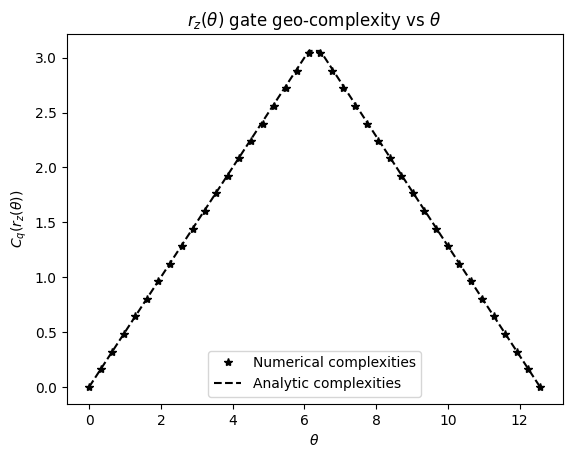

In [2]:
##############################
#rz(theta) gate example
thetas=np.linspace(0,4*np.pi,40)
rz_complexes=[]

for theta in thetas:

    qc_rz=QuantumCircuit(1)
    qc_rz.rz(theta,0)

    rz_complexes.append(GeoComplexity(qc_rz).geocomplex)
    
plt.figure(dpi=100)
plt.plot(thetas,rz_complexes,'k*',label="Numerical complexities")
plt.plot(thetas,abs(np.atan2(np.sin(thetas/2),np.cos(thetas/2))),'k--',label='Analytic complexities')
plt.title(r'$r_z(\theta)$ gate geo-complexity vs $\theta$')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$C_q(r_z(\theta))$')
plt.legend()
plt.savefig('./output/rz_gate_complex.png',dpi=600)
    

In [3]:
##############################
#Random circuit example

In [4]:
#Set circuit parameters for random circuit example
num_gates=100
seed=1
N_qubits=3
qc = random_IBM_circuit(N_qubits,num_gates,seed)

In [5]:
qc.draw('mpl').savefig(f'./output/random_IBM_circuit_{seed}seed.png',dpi=600)

In [6]:
#Calcualte complexity with QGeo
sol_random_geo=GeoComplexity(qc)


100%|██████████| 63.0/63.0 [00:24<00:00,  2.58it/s]                    


In [7]:
#Calcualte gate sum complexity 
sol_random_gateSum=GateSumComplexity(qc)

100%|██████████| 3.0/3.0 [00:00<00:00, 10.45it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00,  9.13it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00,  9.07it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.26it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.29it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 13.63it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 10.41it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 11.29it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 13.62it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 13.68it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.01it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 10.96it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.15it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.20it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 13.56it/s]          

In [8]:
#Check complexity based on gate sum method
sol_random_gateSum

np.float64(127.55315251191519)

In [9]:
#Get complexity with geodesic complilation
sol_random_geo.geocomplex

np.float64(2.484843649648939)

In [10]:
H_coeff_data_Q_rand=sol_random_geo.H_coeff_data_Q
H_coeff_data_P_rand=sol_random_geo.H_coeff_data_p
time_rand=sol_random_geo.time

/opt/anaconda3/envs/QGeoTester/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/QGeoTester/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


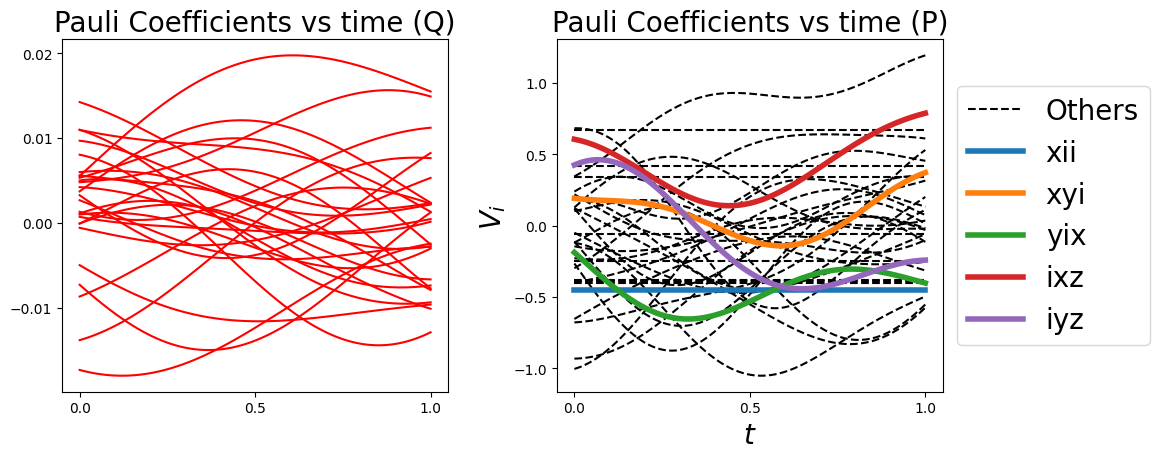

In [11]:
fig,axs=plt.subplots(1,2,figsize=(12,5))

#Make a plot with labels of certain tangent vectors
#Selected tangent vectors for highlighting
num_strings=[0,10,21,29,32]

#Get all p signatures
sigs=[]
for sig in generate_P_signatures(n_qubits=3):
    sigs.append(sig)


axs[0].plot(time_rand,np.array(H_coeff_data_Q_rand)[:,:len(sigs)],color='r') 
axs[1].plot(time_rand,H_coeff_data_P_rand,color='k',ls='--')
axs[1].plot([],[],color='k',ls='--',label='Others')

plt.rcParams.update({'font.size': 20})  # Set the default font size to 14
for num in num_strings:
    axs[1].plot(time_rand,np.array(H_coeff_data_P_rand)[:,num],label=sigs[num],linewidth=4)
    #plt.plot([],[],label='P',color='k')
#plt.legend(loc='upper left',bbox_to_anchor=(1.05,1))

#plt.xlim([0,1.55])
axs[1].set_title('Pauli Coefficients vs time (P)',fontsize='20')
axs[0].set_title('Pauli Coefficients vs time (Q)',fontsize='20')
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel(r'$V_i$',fontsize='20')
plt.xlabel(r'$t$',fontsize='20')
plt.tight_layout()
plt.savefig(f'./output/random_Coeffs_{N_qubits}_qubits.png',dpi=600)
plt.show()




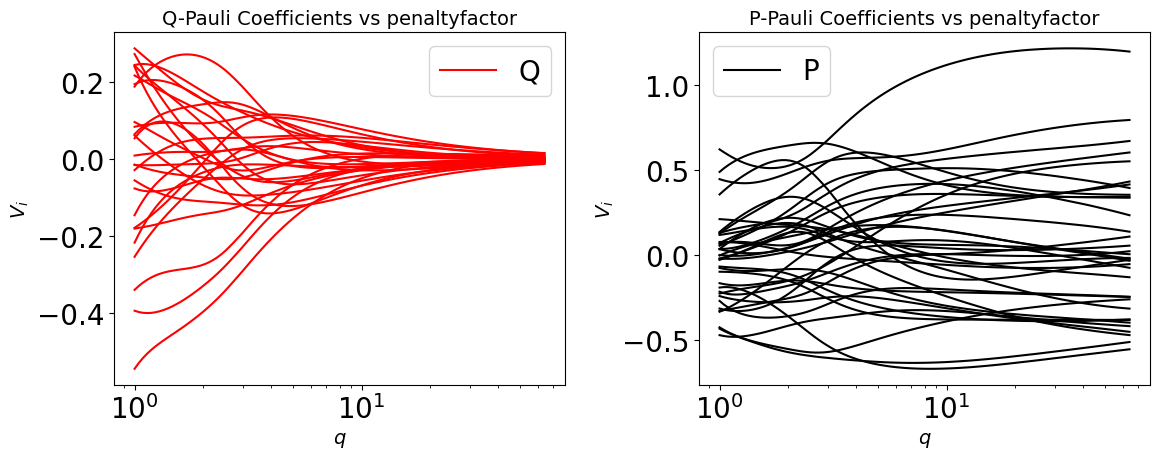

In [12]:
coeff_data_P_rand=sol_random_geo.coeffHistP
coeff_data_Q_rand=sol_random_geo.coeffHistQ
q_vals_rand=sol_random_geo.q_vals

#Make a plot of initial tangent vectors vs. penalty factor.

fig, axs=plt.subplots(1,2,figsize=(12,5))

axs[0].semilogx(q_vals_rand,np.array(coeff_data_Q_rand),color='r')
axs[0].semilogx([],[],label='Q',color='r')
axs[1].semilogx(q_vals_rand,coeff_data_P_rand,color='k')
axs[1].semilogx([],[],label='P',color='k')
axs[0].legend()
axs[1].legend()
axs[0].set_title('Q-Pauli Coefficients vs penaltyfactor',fontsize='14')
axs[1].set_title('P-Pauli Coefficients vs penaltyfactor',fontsize='14')
axs[0].set_ylabel(r'$V_i$',fontsize='14')
axs[1].set_ylabel(r'$V_i$',fontsize='14')
axs[0].set_xlabel(r'$q$',fontsize='14')
axs[1].set_xlabel(r'$q$',fontsize='14')
#axs[0].set_ylim(axs[1].get_ylim())
plt.tight_layout()
plt.savefig(f'./output/rand_{N_qubits}_coeffs_v_q_{seed}_seed.png',dpi=600)
plt.show()

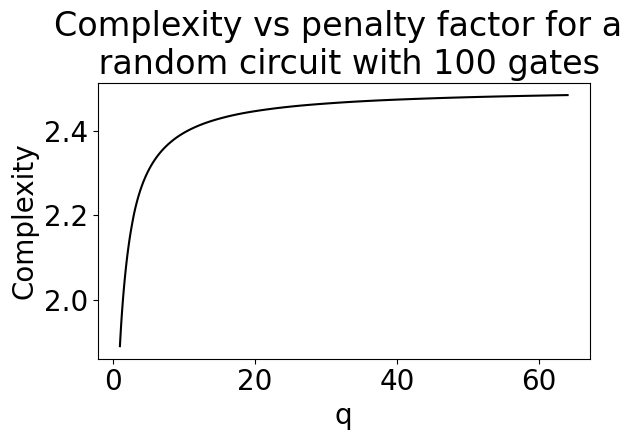

In [13]:
plt.figure(dpi=100)
plt.plot(sol_random_geo.q_vals,sol_random_geo.complexHist,'k')
plt.xlabel('q')
plt.ylabel('Complexity')
plt.title(f'Complexity vs penalty factor for a \n random circuit with {num_gates} gates')
plt.tight_layout()
plt.savefig(f'./output/rand_complex_v_complex_{N_qubits}.png',dpi=600)

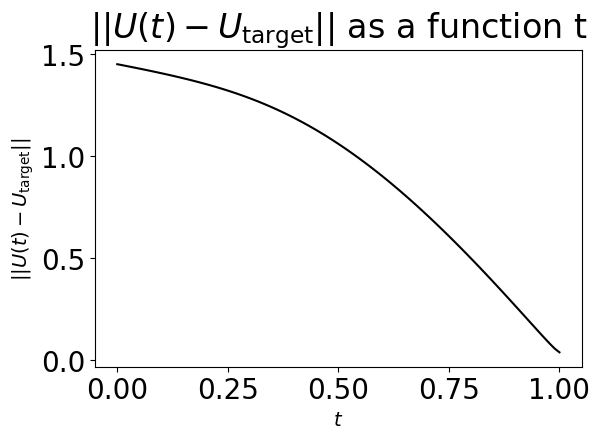

In [14]:
U_norm_data_rand=sol_random_geo.U_norm_data

#Plot residual vs time (should approach zero)
plt.figure()
plt.plot(time_rand,U_norm_data_rand,color='k')
plt.ylabel(r'$||U(t)-U_{\mathrm{target}}||$',fontsize='14')
plt.title(r'$||U(t)-U_{\mathrm{target}}||$ as a function t')
plt.xlabel(r'$t$',fontsize='14')
plt.tight_layout()
plt.savefig(f'./output/du_Rand_{N_qubits}_qubits.png',dpi=600)
plt.show()


In [67]:
#Use convergence tester tool to test convergence.
complexityVNts,Nt_grid,Nq_grid=convergenceTester(qc)

100%|██████████| 63.0/63.0 [00:23<00:00,  2.65it/s]                    
100%|██████████| 63.0/63.0 [00:34<00:00,  1.83it/s]                    
100%|██████████| 63.0/63.0 [00:46<00:00,  1.35it/s]                    
100%|██████████| 63.0/63.0 [01:02<00:00,  1.01it/s]                    
100%|██████████| 63.0/63.0 [00:24<00:00,  2.59it/s]                    
100%|██████████| 63.0/63.0 [00:35<00:00,  1.79it/s]                    
100%|██████████| 63.0/63.0 [00:47<00:00,  1.32it/s]                    
100%|██████████| 63.0/63.0 [01:02<00:00,  1.02it/s]                    
100%|██████████| 63.0/63.0 [00:24<00:00,  2.59it/s]                    
100%|██████████| 63.0/63.0 [00:35<00:00,  1.80it/s]                    
100%|██████████| 63.0/63.0 [00:47<00:00,  1.33it/s]                    
100%|██████████| 63.0/63.0 [01:01<00:00,  1.02it/s]                    
100%|██████████| 63.0/63.0 [00:24<00:00,  2.59it/s]                    
100%|██████████| 63.0/63.0 [00:35<00:00,  1.79it/s]             

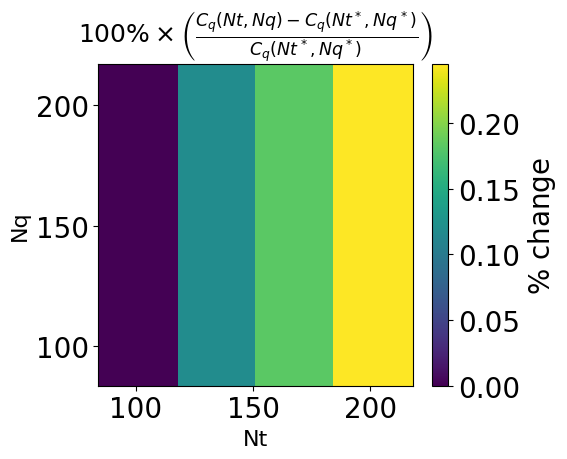

In [68]:
#Plot convergence matrix
from matplotlib import pyplot as plt
plt.figure(figsize=(6,5))
plt.pcolormesh(Nt_grid, Nq_grid, 100*(complexityVNts-complexityVNts[0,0])/complexityVNts[0,0], shading='auto', cmap='viridis')
plt.colorbar(label=r'$\%$ change')
plt.xlabel('Nt',fontsize=16)
plt.ylabel('Nq',fontsize=16)
plt.title(r'$100\%\times\left(\frac{C_q(Nt,Nq)-C_q(Nt^*,Nq^*)}{C_q(Nt^*,Nq^*)}\right)$',fontsize=18)
plt.tight_layout()
plt.savefig(f'./output/convergenceTestSweep_seed_{seed}.png',dpi=600)
plt.show()

In [69]:
#Calculate complexity with tightend tolerances.
sol_solver_params=GeoComplexity(qc,rtol=1e-4,atol=1e-7)

100%|██████████| 63.0/63.0 [00:32<00:00,  1.96it/s]                    


In [71]:
sol_solver_params.geocomplex

np.float64(2.484603068452969)

In [22]:
#################
#QFT examples

In [2]:
N_qubits=4
qft_circuit=qft(N_qubits)

# Transpile to a specific gate set
qft_circuit_transpiled = transpile(qft_circuit, basis_gates=['sx','cz','x','rz'],optimization_level=3,
    seed_transpiler=1)

In [3]:
qft_circuit_transpiled.draw(output='mpl',fold=15).savefig(f'./output/qft_{N_qubits}_qubits.png')

In [ ]:
#output file for gate sum complexities
output_file_qft = Path(f"./output/qft_geoComplexity_{N_qubits}_qubits.pkl")

#if file does not exist create it.
if not output_file_qft.exists():
    # File does not exist — create it
    print("File not found. Creating file...")
    
    output_file_qft.parent.mkdir(parents=True, exist_ok=True)  # Ensure directory exists
    
    sol_qft=GeoComplexity(qft_circuit_transpiled)

    # Save object
    with open(output_file_qft, "wb") as f:
        pickle.dump(sol_qft, f)
else:
    print("File already exists.")
    # Load object
    with open(output_file_qft, "rb") as f:
        sol_qft = pickle.load(f)


File not found. Creating file...


  0%|          | 0/255.0 [00:00<?, ?it/s]/Users/sean/Desktop/QGeoProject/src/QGeo/boilerplate.py:333: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(complex128, 2, 'A', False, aligned=True), Array(complex128, 2, 'F', False, aligned=True))
  p, q = PQ_decomp(x)
  1%|          | 2.709599000206656/255.0 [20:40<10:06:52, 144.33s/it]     

In [21]:
#Measure time and memory consumption of QGeo
import psutil, os
import time

def measure_memory_psutil(func, *args, **kwargs):
    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss  # bytes
    result = func(*args, **kwargs)
    mem_after = process.memory_info().rss
    mem_used = mem_after - mem_before
    print(f"Memory used by function: {mem_used / (1024**2):.2f} MB")
    return result

start_time=time.time()
y = measure_memory_psutil(GeoComplexity,qft_circuit_transpiled )
end_time=time.time()
print(f'Time elapsed during run= {end_time-start_time}')

100%|██████████| 63.0/63.0 [00:14<00:00,  4.39it/s]                    


Memory used by function: 94.22 MB
Time elapsed during run= 16.911794185638428


In [22]:
sol_qft.geocomplex

np.float64(1.9473371619652202)

In [23]:
sol_qft_gateSum=GateSumComplexity(qft_circuit_transpiled)

100%|██████████| 3.0/3.0 [00:00<00:00, 11.24it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 11.19it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 10.18it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00,  9.03it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 11.19it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.03it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00,  8.89it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 10.87it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00,  9.24it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.11it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 10.84it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.78it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 11.23it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 13.56it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.26it/s]        

In [24]:
sol_qft_gateSum

np.float64(33.63784287619309)

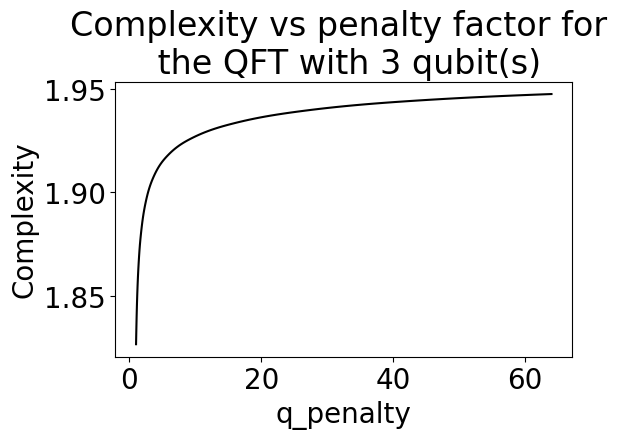

In [25]:
plt.figure(dpi=100)
plt.plot(sol_qft.q_vals,sol_qft.complexHist,'k')
plt.xlabel('q_penalty')
plt.ylabel('Complexity')
plt.title(f'Complexity vs penalty factor for \n the QFT with {N_qubits} qubit(s)')
plt.tight_layout()
plt.savefig(f'./output/qft_complex_v_complex_{N_qubits}.png',dpi=600)

In [2]:

#output file for gate sum complexities
output_file = Path("./output/qft_gateSumComplexities.npy")

#if file does not exist create it.
if not output_file.exists():
    # File does not exist — create it
    print("File not found. Creating file...")
    
    output_file.parent.mkdir(parents=True, exist_ok=True)  # Ensure directory exists
    
    gateSumComplexities_QFT=[]
    for n in range(1,11):
        qft_circuit=qft(n)

        # Transpile to a specific gate set
        qft_circuit_transpiled = transpile(qft_circuit, basis_gates=['sx','cz','x','rz'],optimization_level=3,
            seed_transpiler=1)
        sol_qft_gateSum=GateSumComplexity(qft_circuit_transpiled)
        gateSumComplexities_QFT.append(sol_qft_gateSum)

    np.save(output_file,gateSumComplexities_QFT)
else:
    print("File already exists.")
    gateSumComplexities_QFT=np.load(output_file)


    



        

File already exists.


/opt/anaconda3/envs/QGeoTester/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/QGeoTester/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


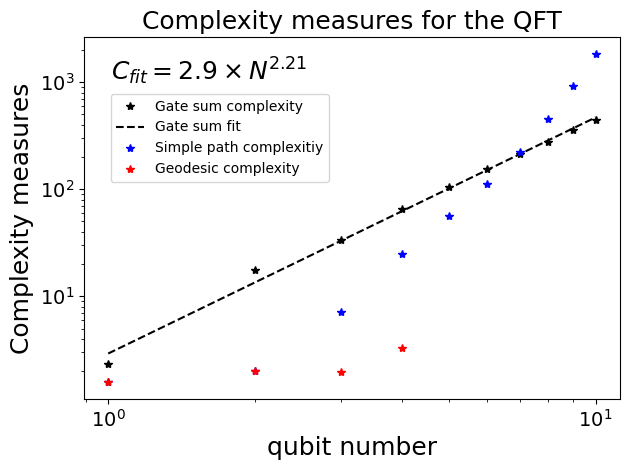

In [5]:
#Plot results computed earlier
import numpy as np
from matplotlib import pyplot as plt
plt.figure(dpi=100)

qft_geo_complexities=[1.5697025957627466,1.999826087243477,1.9472203118160154,3.293657720445508]

qubits_numbers=np.linspace(1,10,10)

log_qubits = np.log10(qubits_numbers)
log_gatesum = np.log10(gateSumComplexities_QFT)
(coeffs,cov) = np.polyfit(log_qubits, log_gatesum, 1,cov=True)
b = coeffs[0]  
db=np.sqrt(cov[0,0])
da=10**(np.sqrt(cov[1,1]))
log_a = coeffs[1]       # intercept
a = 10**log_a           # convert back

simple_path_comps=[]
for n in range(1,11):
    simple_path_comps.append(NaiveComplexity(qft(n)))


plt.loglog(np.linspace(1,10,10),gateSumComplexities_QFT,'k*',label='Gate sum complexity')
plt.loglog(qubits_numbers,a*qubits_numbers**b,'k--',label="Gate sum fit")
plt.loglog(qubits_numbers,simple_path_comps,'b*',label="Simple path complexitiy")
# Add fit equation to plot
eq_text = rf"$C_{{fit}} = {a:.2g} \times N^{{{b:.2f}}}$"
plt.text(0.05, 0.95, eq_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',fontsize=18)

plt.loglog(np.linspace(1,4,4),qft_geo_complexities,'r*',label='Geodesic complexity')
plt.xlabel('qubit number',fontsize=18)
plt.ylabel('Complexity measures',fontsize=18)
plt.title('Complexity measures for the QFT',fontsize=18)
plt.legend(loc=[0.05,0.6])
plt.tick_params(axis='both', which='both', labelsize=14)
plt.tight_layout()
plt.savefig('./output/complexityComparison.png',dpi=600)

In [ ]:
#Print uncertainties for fitted parameters
[da,db]

[np.float64(1.0997433977275812), np.float64(0.057177535089363615)]

In [26]:
H_coeff_data_Q=sol_qft.H_coeff_data_Q
H_coeff_data_P=sol_qft.H_coeff_data_p
time=sol_qft.time

/opt/anaconda3/envs/QGeoTester/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/QGeoTester/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


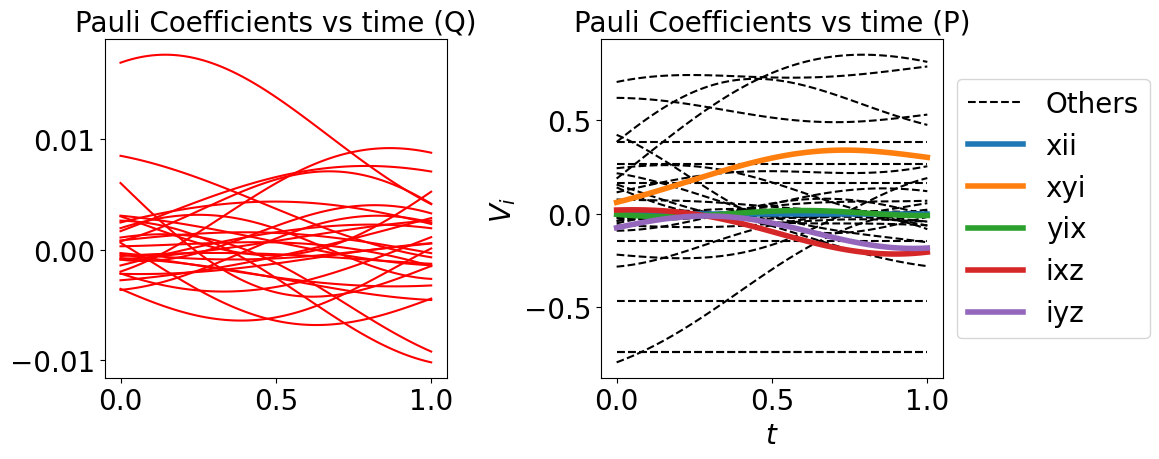

In [27]:
fig,axs=plt.subplots(1,2,figsize=(12,5))

#Make a plot with labels of certain tangent vectors
#Selected tangent vectors for highlighting
num_strings=[0,10,21,29,32]

#Get all p signatures
sigs=[]
for sig in generate_P_signatures(n_qubits=3):
    sigs.append(sig)


axs[0].plot(time,np.array(H_coeff_data_Q)[:,:len(sigs)],color='r') 
axs[1].plot(time,H_coeff_data_P,color='k',ls='--')
axs[1].plot([],[],color='k',ls='--',label='Others')

plt.rcParams.update({'font.size': 20})  # Set the default font size to 14
for num in num_strings:
    axs[1].plot(time,np.array(H_coeff_data_P)[:,num],label=sigs[num],linewidth=4)
    #plt.plot([],[],label='P',color='k')
#plt.legend(loc='upper left',bbox_to_anchor=(1.05,1))

#plt.xlim([0,1.55])
axs[1].set_title('Pauli Coefficients vs time (P)',fontsize='20')
axs[0].set_title('Pauli Coefficients vs time (Q)',fontsize='20')
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel(r'$V_i$',fontsize='20')
plt.xlabel(r'$t$',fontsize='20')
plt.tight_layout()
plt.savefig(f'./output/qft_Coeffs_{N_qubits}_qubits.png',dpi=600)
plt.show()


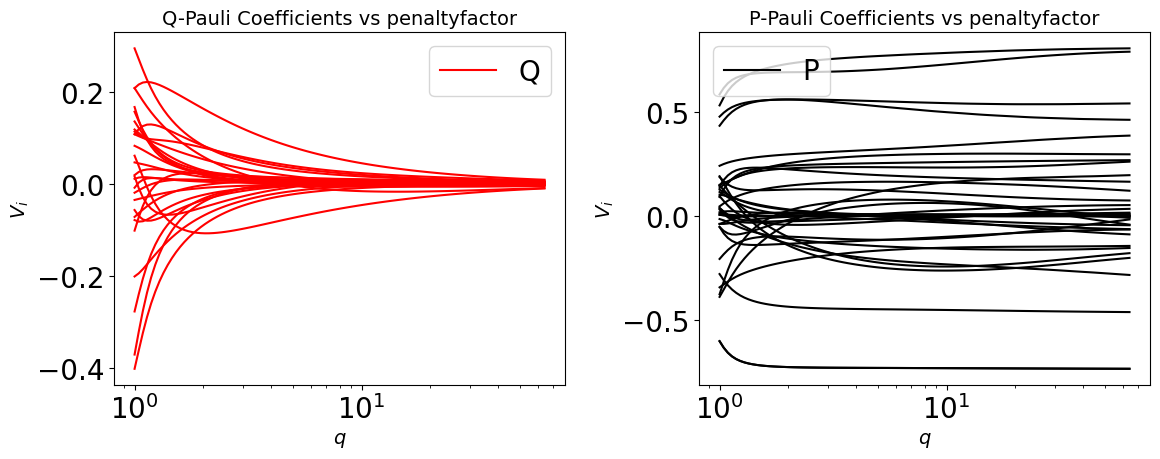

In [28]:
coeff_data_P=sol_qft.coeffHistP
coeff_data_Q=sol_qft.coeffHistQ
q_vals=sol_qft.q_vals

#Make a plot of initial tangent vectors vs. penalty factor.

fig, axs=plt.subplots(1,2,figsize=(12,5))

axs[0].semilogx(q_vals,np.array(coeff_data_Q),color='r')
axs[0].semilogx([],[],label='Q',color='r')
axs[1].semilogx(q_vals,coeff_data_P,color='k')
axs[1].semilogx([],[],label='P',color='k')
axs[0].legend()
axs[1].legend()
axs[0].set_title('Q-Pauli Coefficients vs penaltyfactor',fontsize='14')
axs[1].set_title('P-Pauli Coefficients vs penaltyfactor',fontsize='14')
axs[0].set_ylabel(r'$V_i$',fontsize='14')
axs[1].set_ylabel(r'$V_i$',fontsize='14')
axs[0].set_xlabel(r'$q$',fontsize='14')
axs[1].set_xlabel(r'$q$',fontsize='14')
#axs[0].set_ylim(axs[1].get_ylim())
plt.tight_layout()
plt.savefig(f'./output/QFT_coeffs_v_q_{N_qubits}_qubits.png',dpi=600)
plt.show()

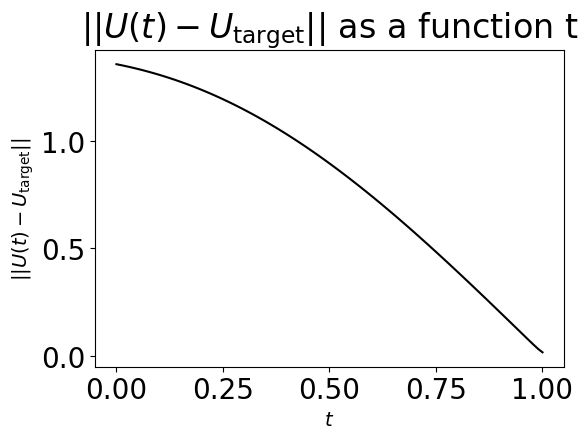

In [29]:
U_norm_data=sol_qft.U_norm_data

#Plot residual vs time (should approach zero)
plt.figure()
plt.plot(time,U_norm_data,color='k')
plt.ylabel(r'$||U(t)-U_{\mathrm{target}}||$',fontsize='14')
plt.title(r'$||U(t)-U_{\mathrm{target}}||$ as a function t')
plt.xlabel(r'$t$',fontsize='14')
plt.tight_layout()
plt.savefig(f'./output/du_QFT_{N_qubits}_qubits.png',dpi=600)
plt.show()


In [30]:
##########################
#### Trotterized Circuit
phi=0.5
qc_trot=QuantumCircuit(4)

qc_trot.rxx(phi,0,1)
qc_trot.rxx(phi,2,3)
qc_trot.ryy(phi,0,1)
qc_trot.ryy(phi,2,3)

qc_trot.rxx(phi,1,2)
qc_trot.ryy(phi,1,2)


# Transpile to a specific gate set
qc_trot_circuit_transpiled = transpile(qc_trot, basis_gates=['sx','cz','x','rz'],optimization_level=3,
    seed_transpiler=1)



In [31]:
qc_trot_circuit_transpiled.draw('mpl').savefig(f'./output/trot_{phi}_qubits.png',dpi=600)

In [32]:
trot_gateSum=GateSumComplexity(qc_trot_circuit_transpiled)

100%|██████████| 3.0/3.0 [00:00<00:00,  9.01it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 11.46it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 12.12it/s]                
100%|██████████| 3.0/3.0 [00:00<00:00, 12.04it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.51it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.44it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 13.83it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.72it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.92it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 11.52it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00,  9.11it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.47it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 12.11it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 11.51it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00,  9.21it/s]           

In [33]:
print(trot_gateSum)

52.33467174372095


In [34]:
#output file for gate sum complexities
output_file_trot = Path(f"./output/trot_geoComplexity_{phi}_qubits.pkl")

#if file does not exist create it.
if not output_file_trot.exists():
    # File does not exist — create it
    print("File not found. Creating file...")
    
    output_file_trot.parent.mkdir(parents=True, exist_ok=True)  # Ensure directory exists
    
    trot_geo_sol=GeoComplexity(qc_trot_circuit_transpiled)

    # Save object
    with open(output_file_trot, "wb") as f:
        pickle.dump(trot_geo_sol, f)
else:
    print("File already exists.")
    # Load object
    with open(output_file_trot, "rb") as f:
        trot_geo_sol= pickle.load(f)

File not found. Creating file...


  1%|          | 2.0522671030892496/255.0 [02:10<2:01:50, 28.90s/it]    

KeyboardInterrupt: 

In [31]:
print(trot_geo_sol.geocomplex)

0.7665798663132404


/opt/anaconda3/envs/QGeoTester/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/QGeoTester/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


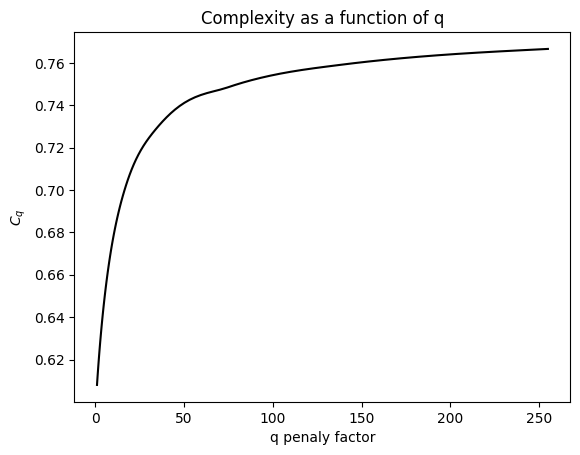

In [32]:
plt.figure()
plt.plot(trot_geo_sol.q_vals,trot_geo_sol.complexHist,'k')
plt.xlabel('q penaly factor')
plt.ylabel(r'$C_q$')
plt.title('Complexity as a function of q')
plt.savefig('trot_geo_complexiy.png',dpi=600)

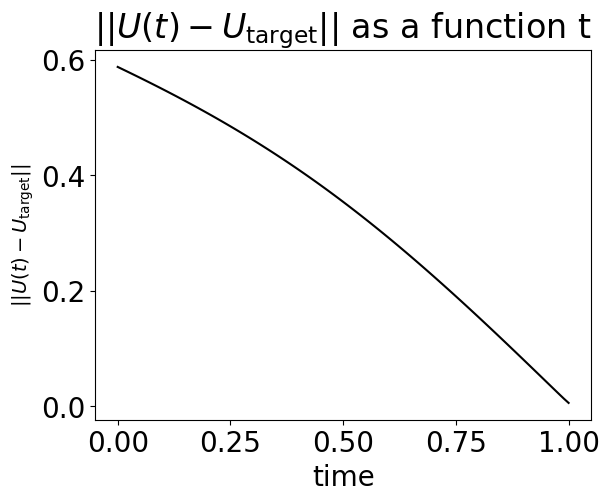

In [44]:
plt.figure()
plt.plot(trot_geo_sol.time,trot_geo_sol.U_norm_data,'k')
plt.xlabel('time')
plt.ylabel(r'$||U(t)-U_{\mathrm{target}}||$',fontsize='14')
plt.title(r'$||U(t)-U_{\mathrm{target}}||$ as a function t')
plt.savefig('trot_geo_residual.png',dpi=600)

In [45]:
##########################
#### Trotterized Circuit (backwards)
phi=0.5
qc_trot_backwards=QuantumCircuit(4)


qc_trot_backwards.rxx(phi,1,2)
qc_trot_backwards.ryy(phi,1,2)

qc_trot_backwards.rxx(phi,0,1)
qc_trot_backwards.rxx(phi,2,3)
qc_trot_backwards.ryy(phi,0,1)
qc_trot_backwards.ryy(phi,2,3)



# Transpile to a specific gate set
qc_trot_backwards_circuit_transpiled = transpile(qc_trot_backwards, basis_gates=['sx','cz','x','rz'],optimization_level=3,
    seed_transpiler=1)


In [46]:
qc_trot_backwards_circuit_transpiled.draw('mpl').savefig(f'./output/trot_backwards_{phi}_qubits.png',dpi=600)

In [47]:
trot_backwards_gateSum=GateSumComplexity(qc_trot_backwards_circuit_transpiled)

100%|██████████| 3.0/3.0 [00:00<00:00,  8.64it/s]                   
100%|██████████| 3.0/3.0 [00:00<00:00, 11.46it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 12.09it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00,  9.22it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 11.43it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 12.04it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 10.68it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 11.52it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.45it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 13.87it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.36it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 12.07it/s]                  
100%|██████████| 3.0/3.0 [00:00<00:00, 11.54it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00,  9.27it/s]                 
100%|██████████| 3.0/3.0 [00:00<00:00, 11.53it/s]      

In [48]:
trot_gateSum

np.float64(52.170035939747244)

In [49]:
#output file for gate sum complexities
output_file_trot_backward = Path(f"./output/trot_backward_geoComplexity_{phi}_qubits.pkl")

#if file does not exist create it.
if not output_file_trot_backward.exists():
    # File does not exist — create it
    print("File not found. Creating file...")
    
    output_file_trot_backward.parent.mkdir(parents=True, exist_ok=True)  # Ensure directory exists
    
    trot_geo_sol_backward=GeoComplexity(qc_trot_backwards_circuit_transpiled)

    # Save object
    with open(output_file_trot_backward, "wb") as f:
        pickle.dump(trot_geo_sol, f)
else:
    print("File already exists.")
    # Load object
    with open(output_file_trot_backward, "rb") as f:
        trot_geo_sol_backward= pickle.load(f)

File already exists.


In [50]:
print(trot_geo_sol_backward.geocomplex)


0.7665798663132404


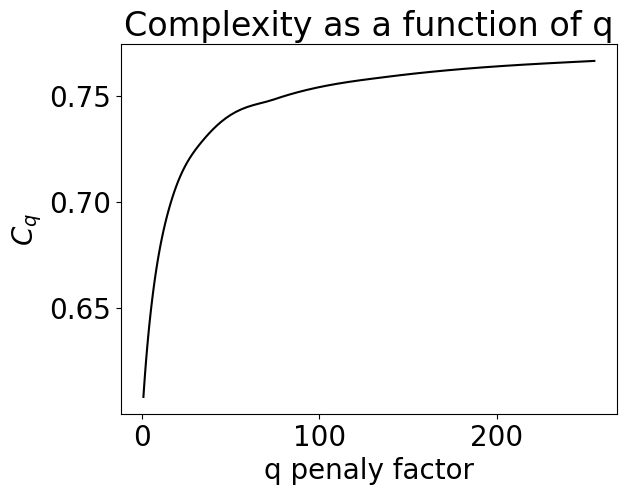

In [51]:
plt.figure()
plt.plot(trot_geo_sol_backward.q_vals,trot_geo_sol_backward.complexHist,'k')
plt.xlabel('q penaly factor')
plt.ylabel(r'$C_q$')
plt.title('Complexity as a function of q')
plt.savefig('trot_backwards_geo_complexiy.png',dpi=600)

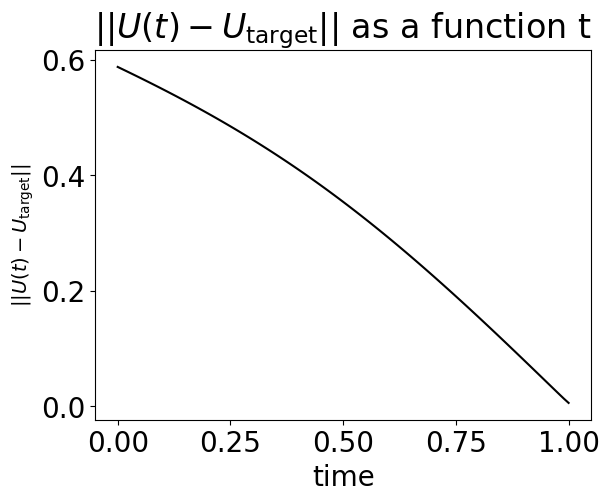

In [52]:
plt.figure()
plt.plot(trot_geo_sol_backward.time,trot_geo_sol_backward.U_norm_data,'k')
plt.xlabel('time')
plt.ylabel(r'$||U(t)-U_{\mathrm{target}}||$',fontsize='14')
plt.title(r'$||U(t)-U_{\mathrm{target}}||$ as a function t')
plt.savefig('trot_backward_geo_residual.png',dpi=600)

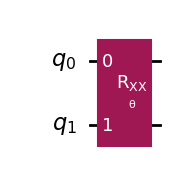

In [10]:
from qiskit.circuit import Parameter
theta = Parameter('θ')
qc_trot_analytic=QuantumCircuit(2)
qc_trot_analytic.rxx(qubit1=0,qubit2=1,theta=theta)
qc_trot_analytic.draw('mpl')

In [11]:
qc_trot_analytic_trans=transpile(qc_trot_analytic,optimization_level=3,seed_transpiler=1,basis_gates=['sx','cz','x','rz'])

In [55]:
qc_trot_analytic_trans.draw('mpl').savefig('./output/rxx_IBM.png',dpi=600)

In [27]:
len(sigs)

36

In [44]:
np.shape(H_coeff_data_P_rand)

(101, 36)

In [45]:
np.shape(H_coeff_data_Q_rand)

(101, 63)